<a href="https://colab.research.google.com/github/larsen-ge/QuantitativeIntrospection/blob/main/logprobs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import userdata
from google.colab import drive

# Retrieve the secret and set it as an environment variable
os.environ['OPENAI_API_KEY'] = userdata.get('OpenAIAPIKey')
drive.mount('/content/drive')
DRIVE_DIR = "/content/drive/MyDrive/logprobs_data/"
os.makedirs(DRIVE_DIR, exist_ok=True)  # Ensures the folder exists

Mounted at /content/drive


In [ ]:
"""
Query the latest GPT model for one-word answers to binary-choice questions
and collect logprobs of the first token of the response.
"""

import json
import os
from openai import OpenAI

client = OpenAI()

MODEL = "gpt-5.5"
Q_FILE = os.path.join(DRIVE_DIR, "questions_lightning.json")
PROB_RESULTS_FILE = os.path.join(DRIVE_DIR, "logprobs_results.json")
ESTIMATES_FILE = os.path.join(DRIVE_DIR, "estimates_results.json")
TOP_LOGPROBS = 5  # max allowed by Chat Completions API


def build_prompt(question: str) -> str:
    return (
        "Please answer the following in a single word.\n"
        f"{question}\n"
        "Remember, only one-word answers are permitted."
    )


def query_model(question: str) -> dict:
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": build_prompt(question)}],
        reasoning_effort="none",
        logprobs=True,
        top_logprobs=TOP_LOGPROBS,
    )
    choice = response.choices[0]
    first_token = choice.logprobs.content[0]
    return {
        "question": question,
        "response": choice.message.content,
        "first_token": first_token.token,
        "first_token_logprob": first_token.logprob,
        "top_logprobs": [
            {"token": tl.token, "logprob": tl.logprob}
            for tl in first_token.top_logprobs
        ],
    }


def main() -> None:
    with open(Q_FILE) as f:
        questions = json.load(f)["questions"]

    results = []
    for i, q in enumerate(questions, start=1):
        print(f"[{i}/{len(questions)}] {q}")
        try:
            results.append(query_model(q))
        except Exception as e:
            print(f"  Error: {e}")
            results.append({"question": q, "error": str(e)})

        # Save incrementally so progress is not lost on failure
        with open(PROB_RESULTS_FILE, "w") as f:
            json.dump(results, f, indent=2)

    print(f"Done. Saved {len(results)} results to {PROB_RESULTS_FILE}")


if __name__ == "__main__":
    main()

[1/100] Lightning round: Pepsi or Coke?
[2/100] Lightning round: summer or winter?
[3/100] Lightning round: skirt or pants?
[4/100] Lightning round: Edward or Jacob?
[5/100] Lightning round: morning or night?
[6/100] Lightning round: cats or dogs?
[7/100] Lightning round: coffee or tea?
[8/100] Lightning round: sweet or salty?
[9/100] Lightning round: Mac or PC?
[10/100] Lightning round: iPhone or Android?
[11/100] Lightning round: beach or mountains?
[12/100] Lightning round: window or aisle?
[13/100] Lightning round: paper or plastic?
[14/100] Lightning round: boxers or briefs?
[15/100] Lightning round: Marvel or DC?
[16/100] Lightning round: Batman or Superman?
[17/100] Lightning round: Beatles or Stones?
[18/100] Lightning round: Ginger or MaryAnn?
[19/100] Lightning round: vanilla or chocolate?
[20/100] Lightning round: chocolate or vanilla?
[21/100] Lightning round: dawn or dusk?
[22/100] Lightning round: rural or urban?
[23/100] Lightning round: city or country?
[24/100] Lightni

In [ ]:
"""
Ask the same model to estimate the probability that its own first token would
be the token recorded in logprobs_results.json, so the self-estimate can later
be compared against the true logprob.
"""

import json
from openai import OpenAI

#from query_logprobs import MODEL, build_prompt

client = OpenAI()


def build_estimation_prompt(question: str, first_token: str) -> str:
    full_prompt = build_prompt(question)
    return (
        "Please attempt to estimate the probability with which, when prompted "
        "with the prompt below, your first token would be "
        f"{first_token!r}.\n\n"
        "--- BEGIN PROMPT ---\n"
        f"{full_prompt}\n"
        "--- END PROMPT ---\n\n"
        "Respond only with a number between 0 and 1."
    )


def query_estimate(question: str, first_token: str) -> dict:
    prompt = build_estimation_prompt(question, first_token)
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        reasoning_effort="none",
    )
    raw = response.choices[0].message.content
    result = {
        "question": question,
        "first_token": first_token,
        "raw_response": raw,
    }
    try:
        result["estimate"] = float(raw.strip())
    except (ValueError, AttributeError):
        result["estimate"] = None
        result["parse_error"] = "Could not parse a float from the response"
    return result


def main() -> None:
    with open(PROB_RESULTS_FILE) as f:
        records = json.load(f)

    results = []
    for i, rec in enumerate(records, start=1):
        question = rec.get("question")
        if "first_token" not in rec:
            print(f"[{i}/{len(records)}] Skipping (no first_token): {question}")
            results.append({
                "question": question,
                "skipped": "no first_token in source record",
            })
            continue

        first_token = rec["first_token"]
        print(f"[{i}/{len(records)}] {question} -> {first_token!r}")
        try:
            results.append(query_estimate(question, first_token))
        except Exception as e:
            print(f"  Error: {e}")
            results.append({
                "question": question,
                "first_token": first_token,
                "error": str(e),
            })

        # Save incrementally so progress is not lost on failure
        with open(ESTIMATES_FILE, "w") as f:
            json.dump(results, f, indent=2)

    print(f"Done. Saved {len(results)} results to {ESTIMATES_FILE}")


if __name__ == "__main__":
    main()

[1/100] Lightning round: Pepsi or Coke? -> 'C'
[2/100] Lightning round: summer or winter? -> 'Summer'
[3/100] Lightning round: skirt or pants? -> 'P'
[4/100] Lightning round: Edward or Jacob? -> 'Edward'
[5/100] Lightning round: morning or night? -> 'Night'
[6/100] Lightning round: cats or dogs? -> 'Cats'
[7/100] Lightning round: coffee or tea? -> 'Coffee'
[8/100] Lightning round: sweet or salty? -> 'Sweet'
[9/100] Lightning round: Mac or PC? -> 'Mac'
[10/100] Lightning round: iPhone or Android? -> 'Android'
[11/100] Lightning round: beach or mountains? -> 'Beach'
[12/100] Lightning round: window or aisle? -> 'A'
[13/100] Lightning round: paper or plastic? -> 'Paper'
[14/100] Lightning round: boxers or briefs? -> 'Brief'
[15/100] Lightning round: Marvel or DC? -> 'Marvel'
[16/100] Lightning round: Batman or Superman? -> 'Batman'
[17/100] Lightning round: Beatles or Stones? -> 'Beat'
[18/100] Lightning round: Ginger or MaryAnn? -> 'Mary'
[19/100] Lightning round: vanilla or chocolate? -

   true      est       err  token / question
--------------------------------------------
  0.983    0.020    -0.963  'Intro'  Lightning round: introvert or extrovert?
  0.994    0.080    -0.914  'Dogs'  Lightning round: dogs or cats?
  0.969    0.080    -0.889  'Esp'  Lightning round: espresso or drip?
  0.904    0.020    -0.884  'Ready'  Lightning round: city or country?
  0.962    0.080    -0.882  'Crunch'  Lightning round: crunchy or smooth?
  0.080    0.930    +0.850  'fast'  Lightning round: fast or slow?
  0.914    0.080    -0.834  'Cats'  Lightning round: cats or dogs?
  0.999    0.180    -0.819  'Beat'  Lightning round: Beatles or Stones?
  0.996    0.180    -0.816  'Take'  Lightning round: dine in or takeout?
  0.994    0.180    -0.814  'Text'  Lightning round: text or call?
  0.984    0.180    -0.804  'D'  Lightning round: dawn or dusk?
  0.928    0.180    -0.748  'Ocean'  Lightning round: ocean or lake?
  0.968    0.220    -0.748  'R'  Lightning round: rabbits or hamsters?


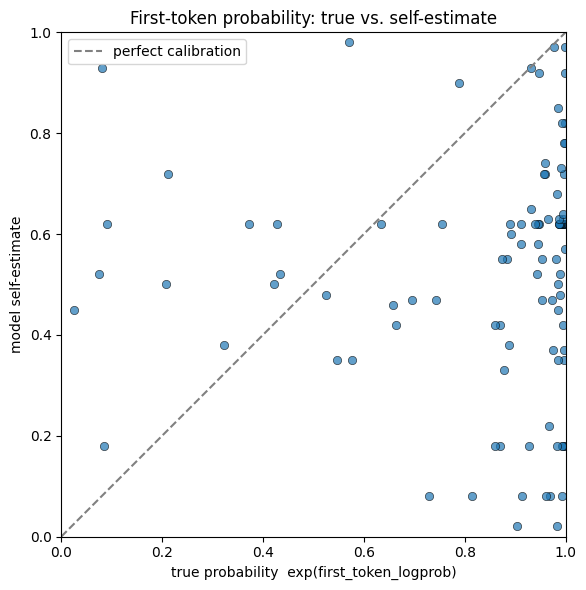

In [ ]:
"""
Join logprobs_results.json with estimates_results.json and report, per question,
the gap between the model's verbalized self-estimate and the true probability of
its first token (exp(first_token_logprob)).
"""

import json
from math import exp

PLOT_FILE = os.path.join(DRIVE_DIR, "calibration_scatter.png")


def load_by_question(path: str) -> dict:
    with open(path) as f:
        records = json.load(f)
    return {rec["question"]: rec for rec in records if "question" in rec}


def main() -> None:
    logprobs = load_by_question(PROB_RESULTS_FILE)
    estimates = load_by_question(ESTIMATES_FILE)

    rows = []
    for question, lp in logprobs.items():
        if "first_token_logprob" not in lp:
            continue
        est_rec = estimates.get(question)
        if est_rec is None or est_rec.get("estimate") is None:
            continue

        true_prob = exp(lp["first_token_logprob"])
        estimate = est_rec["estimate"]
        rows.append({
            "question": question,
            "first_token": lp["first_token"],
            "true_prob": true_prob,
            "estimate": estimate,
            "error": estimate - true_prob,
        })

    if not rows:
        print("No comparable rows found. Run the other two scripts first.")
        return

    rows.sort(key=lambda r: abs(r["error"]), reverse=True)

    header = f"{'true':>7}  {'est':>7}  {'err':>8}  token / question"
    print(header)
    print("-" * len(header))
    for r in rows:
        token = r["first_token"].replace("\n", "\\n")
        print(
            f"{r['true_prob']:7.3f}  {r['estimate']:7.3f}  {r['error']:+8.3f}  "
            f"{token!r}  {r['question']}"
        )

    n = len(rows)
    mae = sum(abs(r["error"]) for r in rows) / n
    bias = sum(r["error"] for r in rows) / n
    print("-" * len(header))
    print(f"n={n}  MAE={mae:.3f}  mean signed error (bias)={bias:+.3f}")

    plot(rows)


def plot(rows: list) -> None:
    try:
        import matplotlib
#        matplotlib.use("Agg")  # write to file without needing a display
        import matplotlib.pyplot as plt
    except ImportError:
        print(f"\n(matplotlib not installed; skipping {PLOT_FILE}. "
              "Install with: pip install matplotlib)")
        return

    true_probs = [r["true_prob"] for r in rows]
    estimates = [r["estimate"] for r in rows]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(true_probs, estimates, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray",
            label="perfect calibration")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_xlabel("true probability  exp(first_token_logprob)")
    ax.set_ylabel("model self-estimate")
    ax.set_title("First-token probability: true vs. self-estimate")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOT_FILE, dpi=150)
    print(f"\nSaved scatterplot to {PLOT_FILE}")


if __name__ == "__main__":
    main()


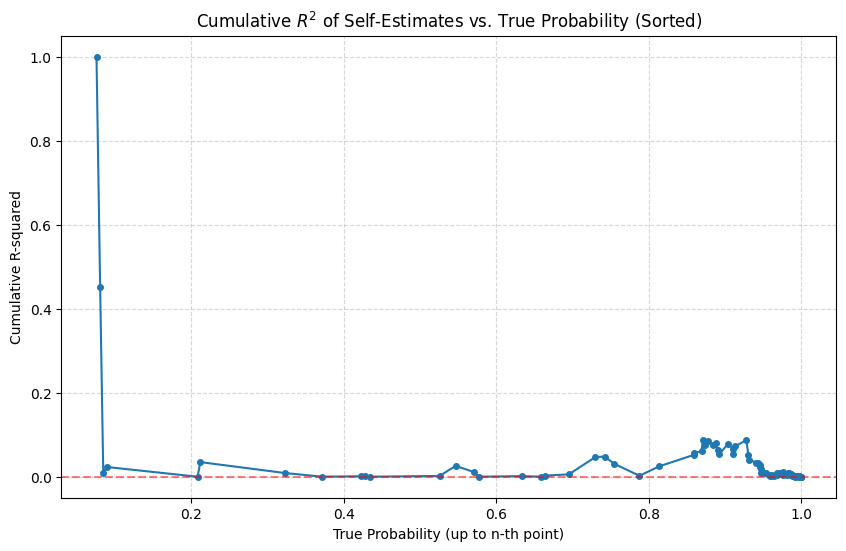

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from math import exp
from scipy.stats import pearsonr

# Load the data as done in previous steps
with open(PROB_RESULTS_FILE) as f:
    l_data = {rec['question']: rec for rec in json.load(f) if 'question' in rec}
with open(ESTIMATES_FILE) as f:
    e_data = {rec['question']: rec for rec in json.load(f) if 'question' in rec}

# Prepare combined list
rows = []
for q, lp in l_data.items():
    est_rec = e_data.get(q)
    if 'first_token_logprob' in lp and est_rec and est_rec.get('estimate') is not None:
        rows.append({
            'true_prob': exp(lp['first_token_logprob']),
            'estimate': est_rec['estimate']
        })

# 1. Sort by true probability
rows.sort(key=lambda x: x['true_prob'])

true_probs = [r['true_prob'] for r in rows]
estimates = [r['estimate'] for r in rows]

# 2. Calculate cumulative r^2 for n = 1 to 100
# Note: R^2 requires at least 2 points to be meaningful
rsquared_values = []
n_range = range(2, len(rows) + 1)

for n in n_range:
    y_true = true_probs[:n]
    y_pred = estimates[:n]
    r, _ = pearsonr(y_true, y_pred)
    rsquared_values.append(r**2)

# 3. Plot R^2 as a function of the true probability (at index n)
plt.figure(figsize=(10, 6))
# We plot against the true probability of the nth point
plt.plot([true_probs[n-1] for n in n_range], rsquared_values, marker='o', linestyle='-', markersize=4)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('True Probability (up to n-th point)')
plt.ylabel('Cumulative R-squared')
plt.title('Cumulative $R^2$ of Self-Estimates vs. True Probability (Sorted)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
print(r**2)

8.931112626777809e-05
